# CS 133 Final Spring 2026
**Your name:**

# US Health Insurance

SAHIE is the Small Area Health Insurance Estimates program of the U.S. Census Bureau. SAHIE estimates of health insurance coverage for counties and states. SAHIE publishes STATE and COUNTY estimates of population with and without health insurance coverage.

Data Source Credit: Small Area Health Insurance Estimates Program, U.S. Census Bureau.

This dataset is not clean and some of the rows do not make sense and you will have to clean it and filter it before starting your analysis.

You have been assigned to do analysis on this dataset and predict the percent uninsured in demographic group for all income levels.

The dataset you will be using can be found at [https://raw.githubusercontent.com/CS133-DataVisualization/CS133_SP26_datafile/refs/heads/main/Datasets/sahie.csv](https://raw.githubusercontent.com/CS133-DataVisualization/CS133_SP26_datafile/refs/heads/main/Datasets/sahie.csv)



## Cleaning your data
Do the initial exploring and ask yourself
* Were there any features that had many missing values that had to be corrected for?
* Are there duplicates?
*   Did all the data import in as expected?
    * correct datatypes
    * values within expected range
    * consistent formatting




In [27]:
### Your code

#importing pandas to create the dataframe 
import pandas as pd

# when I tried reading normally it gave a UnicodeError, changed the encoding to latin_1 after looking it up on pandas website, it loaded
df_test = pd.read_csv('sahie.csv', encoding = 'latin_1')

# original heaed check did not show enough, increased range and we can see some of the data now 
df_test.head(30)

# column names and datapoints underthem seem to match up. No extra commas at the end of the lines for mismatches, values also seem correct for the decsription of the data

,"#Modified dataset. Original Data Source Credit: Small Area Health Insurance Estimates Program, U.S. Census Bureau. (https://stanfordphs.redivis.com/datasets/4mz7-dh26w34ns)",Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15
0,# Here are the descriptions of this dataset:,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,# yearÊ- Year of Estimate,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,# statefipsÊ- Unique FIPS code for each state,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,# countyfipsÊ- Unique FIPS code for each count...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,"# geocatÊ- Geography category, 40 Ð State geog...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,# agecatÊ- Age category,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,# racecatÊ- Race category,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,# sexcatÊ- Sex category,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,# iprcatÊ- Income category,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,# NIPRÊ- Number in demographic group for incom...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [36]:
# skip all the decsription rows, go straight to labeled rows, adding na values for missing values as well
df = pd.read_csv('sahie.csv', 
na_values = ['-', 'nan', 'missing'], 
skiprows = 19, 
encoding = 'latin_1')

# checking data describe
df.describe()

,year,statefips,countyfips,geocat,NIPR,NUI,NIC,PCTUI,PCTIC,PCTELIG,PCTLIIC
count,5544.0,5544.000000,5544.0,5544.0,5.544000e+03,5.544000e+03,5.544000e+03,5541.000000,5531.000000,5536.000000,5544.000000
mean,2020.0,27.680556,0.0,40.0,1.317476e+05,2.545482e+04,1.062928e+05,20.681574,79.326107,8.001842,29.793416
std,0.0,14.684998,0.0,0.0,2.434294e+05,6.157619e+04,1.933839e+05,11.397014,11.395732,6.069234,13.600066
min,2020.0,1.000000,0.0,40.0,6.700000e+01,8.000000e+00,5.800000e+01,2.900000,36.700000,0.200000,4.800000
25%,2020.0,16.000000,0.0,40.0,1.142950e+04,2.052750e+03,8.599500e+03,11.800000,72.500000,3.600000,19.100000
50%,2020.0,28.000000,0.0,40.0,4.823500e+04,8.692000e+03,3.734300e+04,18.000000,82.000000,6.300000,29.500000
75%,2020.0,39.000000,0.0,40.0,1.475280e+05,2.571200e+04,1.197942e+05,27.600000,88.200000,10.900000,38.000000
max,2020.0,56.000000,0.0,40.0,3.378489e+06,1.095236e+06,2.804127e+06,63.300000,97.100000,38.700000,71.800000


In [41]:
# checking data info to check Dtypes
df.info()

# the data that is supposed to be percentage is showing up as object instead of float or int.

# updated the csv read to do add na_Values which fixed percentages

# checking if a lot got taken out, values are small enough to ignore
df.isna().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5544 entries, 0 to 5543
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   year        5544 non-null   int64  
 1   statefips   5544 non-null   int64  
 2   countyfips  5544 non-null   int64  
 3   geocat      5544 non-null   int64  
 4   agecat      5544 non-null   object 
 5   racecat     5544 non-null   object 
 6   sexcat      5544 non-null   object 
 7   iprcat      5544 non-null   object 
 8   NIPR        5544 non-null   int64  
 9   NUI         5544 non-null   int64  
 10  NIC         5544 non-null   int64  
 11  PCTUI       5541 non-null   float64
 12  PCTIC       5531 non-null   float64
 13  PCTELIG     5536 non-null   float64
 14  PCTLIIC     5544 non-null   float64
 15  state_name  5537 non-null   object 
dtypes: float64(4), int64(7), object(5)
memory usage: 693.1+ KB


year           0
statefips      0
countyfips     0
geocat         0
agecat         0
racecat        0
sexcat         0
iprcat         0
NIPR           0
NUI            0
NIC            0
PCTUI          3
PCTIC         13
PCTELIG        8
PCTLIIC        0
state_name     7
dtype: int64

In [ ]:
# checking into PCTUI, PCTIC, and PCTELIG to see what might be causing the issue, changed the line of code to be specific to what I want to check since I am doing it one at a time

df["PCTIC"].unique()

# PCTUI: nan value and - in there as well. also some whole numbers not sure if that is causing an issue with float vs int, going to add na values to my df line

# PCTIC: value labeled 'missing', will add that to na values, also nan 

# PCTELIG: also had 'missing' 

# all percentages now fixed 

array([72.3, 74.7, 68.5, 80.8, 84.8, 77.1, 79.2, 74.2, 84.1, 88.2, 73. ,
       70.3, 79. , 83.6, 81.7, 83. , 80. , 85.4, 88.9, 44.6, 47.4, 40.9,
       53.5, 59.7, 52.3, 55.3, 48.2, 61. , 77. , 78.8, 74.1, 83.5, 86.9,
       80.1, 78.1, 88.7, 74.3, 76. , 71.3, 79.9, 85. , 84.5, 85.8, 82.5,
       87.9, 91.5, 56. , 58.4, 53.4, 62.9, 67.2, 60.3, 63.1, 57.5, 67.5,
       72.9, 70.9, 73.3, 67.9, 82.8, 75.9, 78. , 87.2, 70.4, 71.8, 68.1,
       75.6, 79.3, 80.3, 81.5, 78.6, 83.9, 87.7, 42.2, 45.4, 38.3, 51.6,
       58.6, 54.4, 56.8, 51.2, 61.8, 69.5, 78.2, 79.4, 82.2, 86.1, 71.5,
       71.7, 75.5, 79.6, 79.8, 81.4, 76.9, 81.9, 82.3, 83.8, 60.4, 60.9,
       64.3, 65.8, 62.4, 59.3, 66.7, 70.2, 73.9, 72.7, 81.3, 78.7, 77.9,
       80.5, 80.6, 80.2, 83.2, 83.3, 63.9, 64.6, 64. , 67.1, 68.3, 66.9,
       66.2, 73.2, 73.8, 74.5, 81.6, 85.1, 86.2, 71.6, 71.4, 75.7, 82.6,
       58.8, 59.9, 58.3, 63.7, 65.6, 63.5, 64.7, 62.2, 68.6, 65.2, 70. ,
       70.8, 69.4, 73.5, 82.1, 82. , 85.2, 85.6, 87

In [49]:
# checking if there are duplicates
df.duplicated().sum()

df[df.duplicated()]

df[df.duplicated(keep=False)]


# there were four duplicates so I will drop them 
df = df.drop_duplicates()



***Your conclusions:***   
Please provide your findings involving the cleaning and quality control of the dataset.

The main cleaning I did was skipping the first 19 rows, so I could get to the real dataset since the first rows were decsribing what each column held

Then I checked the info to see what values were not the right object, and found the percentages had na values, so I added na_values to the df field to ignore them. I checked the count of the values to make sure ignoring them will not affect the dataset in a major way. From the findings they will not. I have not removed them at this point, but just not counted them. 

Checked duplicates as well, there were 4 so I just dropped them from the dataset 

# Initial exploration of data
Do some initial exploration of your data. Your goal is to look at the distibution and relations to your data. Some example questions you can explore include:

*   What does the distribution of PCTELIG look like? Explain what this distribution suggest.

*   How would you visualize the relationships between numerical features and PCTELIG. What does the visualization and relationship suggest?
*  Look at the distribution and impact of categorical features (eg., state_name, racecat, or sexcat). Which type of visualization would you use to analyze the impact of categorical features like state_name, racecat, or sexcat.



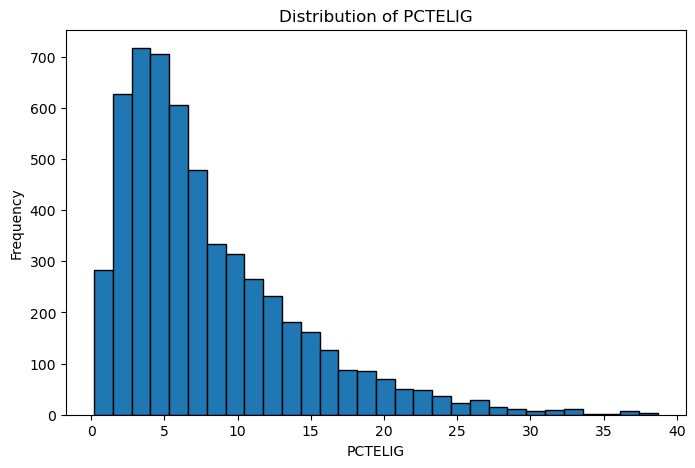

In [ ]:
### Your code

import matplotlib.pyplot as plt

# graphing the distribution of PCTELIG to understand how the target variable is spread out
# this should show whether most areas have low, medium, or high eligible uninsured percentages


# setting the figure size so the graph is easier to read
plt.figure(figsize=(8, 5))

# dropping na only for this graph because I do not want missing values to cause issues in the histogram
# not changing the actual dataframe here, just removing missing values temporarily for the visualization
plt.hist(df["PCTELIG"].dropna(), bins=30, edgecolor="black")

# adding titles and axis labels
plt.title("Distribution of PCTELIG")
plt.xlabel("PCTELIG")
plt.ylabel("Frequency")

plt.show()

The distribution of PCTELIG appears right-skewed, meaning most demographic groups have lower uninsured percentages, while fewer groups have very high uninsured percentages. Most values are concentrated around the lower range, but there are some higher values that stretch the distribution to the right.

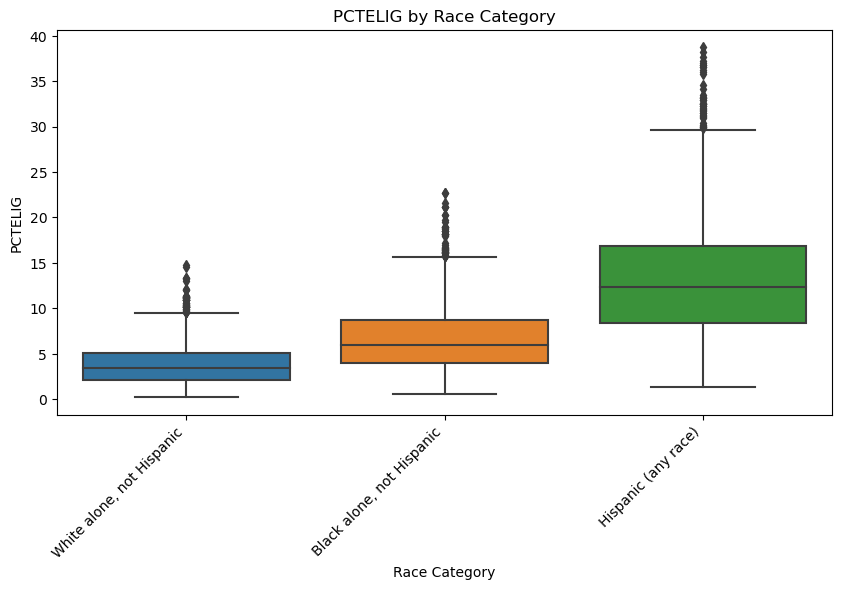

In [ ]:
# creating a boxplot to compare PCTELIG across different race categories
# this helps show if some race groups have higher or lower eligible uninsured percentages

plt.figure(figsize=(10, 5))

# using a boxplot because it shows the median, spread, and possible outliers for each race category
sns.boxplot(data=df, x="racecat", y="PCTELIG")

# adding titles and axis labels
plt.title("PCTELIG by Race Category")
plt.xlabel("Race Category")
plt.ylabel("PCTELIG")

# rotating x-axis labels so the race category names are easier to read, on the first pass it was hard, just looked this up on matplotlib
plt.xticks(rotation=45, ha="right")

plt.show()

The race category boxplot shows that PCTELIG differs by race category. The Hispanic category appears to have the highest median PCTELIG and a wider spread, while White, alone not Hispanic appears lower overall. This suggests race category may be an important feature for predicting uninsured percentage.

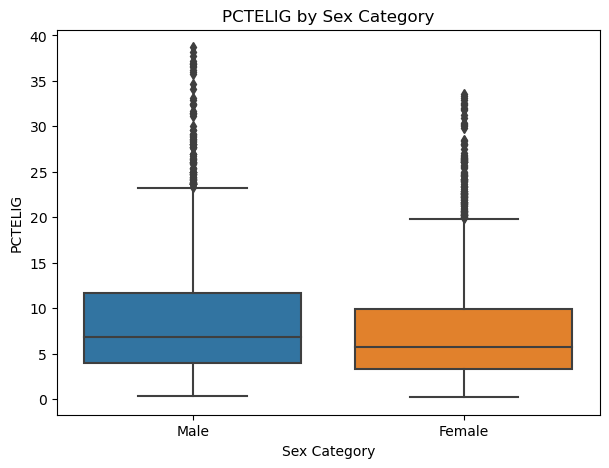

In [ ]:
# creating a boxplot to compare PCTELIG across sex categories
# this helps show if eligible uninsured percentages are different between sex groups

plt.figure(figsize=(7, 5))

# using a boxplot again
sns.boxplot(data=df, x="sexcat", y="PCTELIG")

# adding titles and axis labels
plt.title("PCTELIG by Sex Category")
plt.xlabel("Sex Category")
plt.ylabel("PCTELIG")

plt.show()

The sex category boxplot shows that male and female groups have similar distributions, but males appear to have a slightly higher median and more high outliers. This suggests sex category may have some relationship with PCTELIG, but the difference is not as large as the race category differences.

Your conclusions:
Please provide your findings involving the initial data exploration.

The initial exploration shows that PCTELIG is right-skewed, meaning most demographic groups have lower uninsured percentages while fewer groups have very high uninsured percentages. The histogram shows that many values are concentrated in the lower range, with fewer observations extending toward higher percentages.

The race category boxplot suggests that race category has a noticeable relationship with PCTELIG. The Hispanic category appears to have the highest median uninsured percentage and a wider spread, while White, alone not Hispanic appears lower overall. This suggests racecat may be an important feature when predicting PCTELIG.

The sex category boxplot shows that male and female groups have similar distributions, but males appear to have a slightly higher median and more high outliers. This suggests sexcat may have some relationship with PCTELIG, but the difference is not as strong as the race category differences.

## String data manipulation
To get the average `NUI` (number of uninsured people) in descending order, use the following columns; `iprcat`, `racecat, `NUI`, `state_name`. Notice the `state_name` contains the name of the state followed by some spaces and three dots. For example: Alabama ... You will need to remove the trailing spaces and the three dots and store the cleaned state name in a new column. Then create a dataframe that shows the average NUI for income level iprcat = Between 138% - 400% of poverty for each state. Sort the dataframe by the average NUI in descending order.

In [75]:
### Your code

# after first showing I noticed the state name had 3 dots after it and spaces for some reason that I did not see before 
# cleaning the state_name column to take these out
# making a new column so the original state_name column is still kept in case I need it
df["state_name_clean"] = (
    df["state_name"]
    .str.replace("...", "", regex=False)
    .str.strip()
)

# filtering to only look at the income category between 138% and 400% of poverty
# this matches the specific group for the question
filtered_df = df[df["iprcat"] == "Between 138% - 400% of poverty"]

# grouping by the cleaned state name and finding the average NUI for each state
# resetting the index so the result becomes a regular dataframe
avg_nui_by_state = (
    filtered_df
    .groupby("state_name_clean")["NUI"]
    .mean()
    .reset_index()
)

# sorting by NUI in descending order so the states with the highest average uninsured count show first
avg_nui_by_state = avg_nui_by_state.sort_values(
    by="NUI",
    ascending=False
)

# displaying the final dataframe
avg_nui_by_state

,state_name_clean,NUI
43,Texas,271050.923077
4,California,125618.291667
9,Florida,124814.227273
10,Georgia,56746.708333
33,North Carolina,48585.083333
2,Arizona,41292.000000
13,Illinois,41029.000000
32,New York,40178.291667
35,Ohio,34552.625000
38,Pennsylvania,33607.173913


## Box plots
Create a grouped (multiple) Box Plots using the columns `racecat`, `iprcat`, `PCTUI`, and `PCTIC` to visualize the percent insured and uninsured in different demographic groups (`racecat`) at two different income categories (`iprcat`): At or below 400% of poverty and Between 138% - 400% of poverty.

*   `PCTUI` - Percent uninsured in demographic group for income category

*   `PCTIC` - Percent insured in demographic group for income category

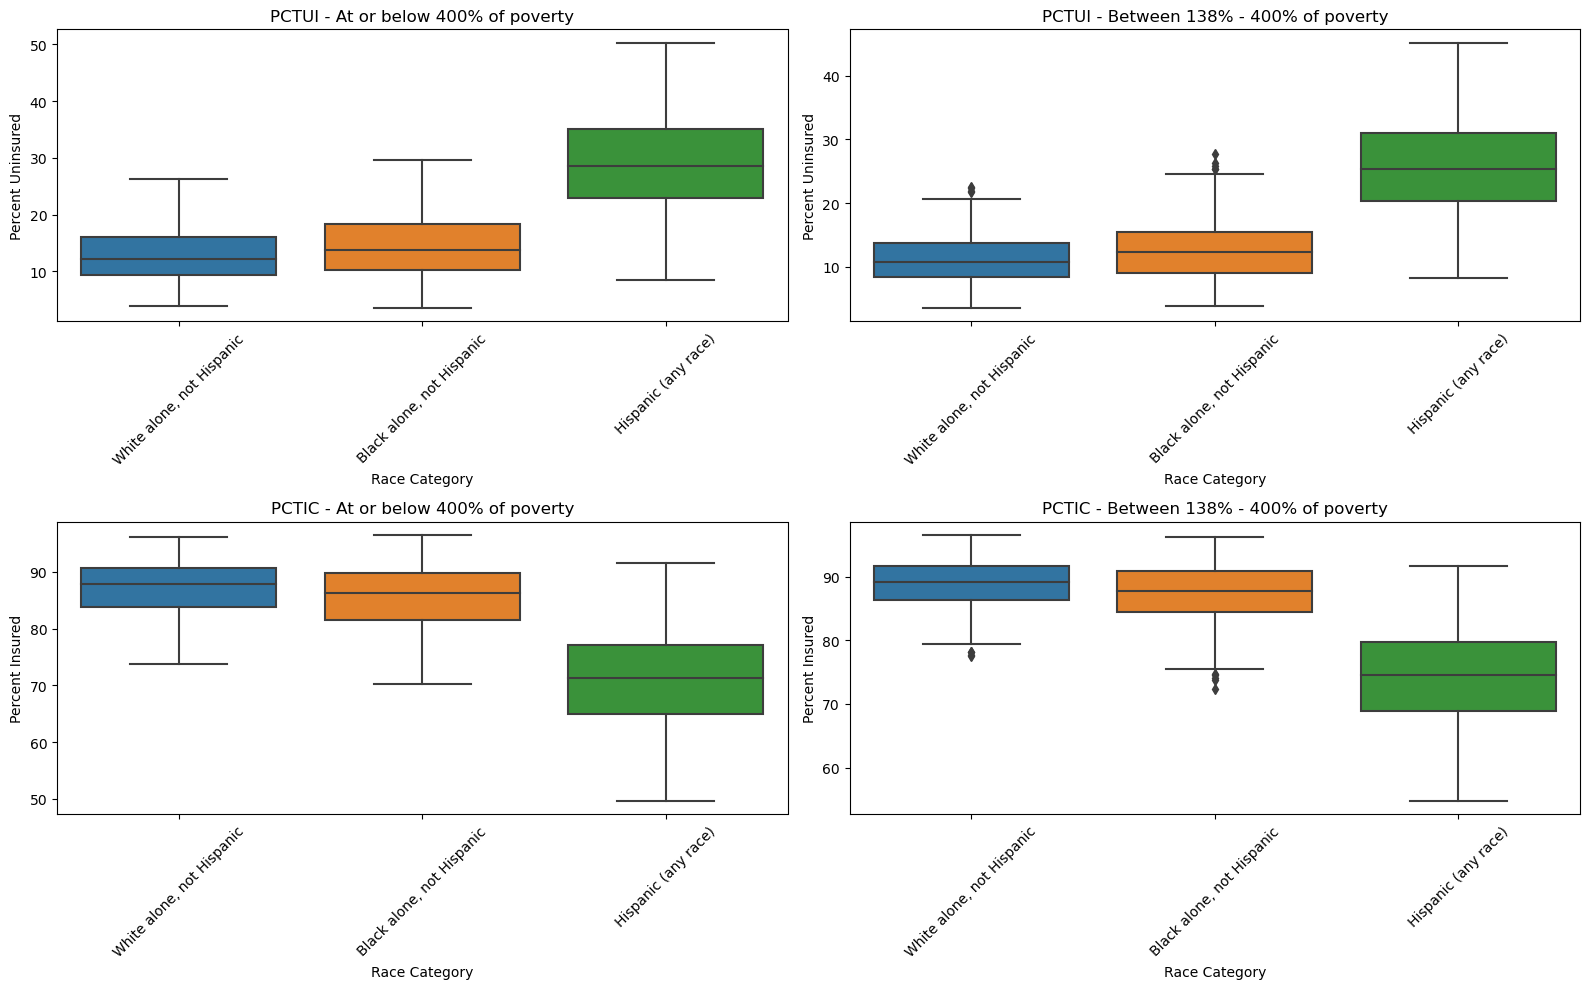

In [ ]:
### Your code

# listing the two income categories that the question wants to compare
income_categories = [
    "At or below 400% of poverty",
    "Between 138% - 400% of poverty"
]

# filtering the dataframe so the graph only uses the two categories
box_df = df[df["iprcat"].isin(income_categories)]

# creating separate charts so I can compare PCTUI and PCTIC 
# rows separate insured vs uninsured and columns separate the income categories
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# looping through the income categories so each column shows one income group
for col, income in enumerate(income_categories):

    # filtering to one income category at a time
    income_df = box_df[box_df["iprcat"] == income]

    # graphing percent uninsured for this income category
    sns.boxplot(
        data=income_df,
        x="racecat",
        y="PCTUI",
        ax=axes[0, col]
    )

    # adding title and labels for the uninsured chart
    axes[0, col].set_title(f"PCTUI - {income}")
    axes[0, col].set_xlabel("Race Category")
    axes[0, col].set_ylabel("Percent Uninsured")

    # graphing percent insured for this income category
    sns.boxplot(
        data=income_df,
        x="racecat",
        y="PCTIC",
        ax=axes[1, col]
    )

    # adding title and labels for the insured chart
    axes[1, col].set_title(f"PCTIC - {income}")
    axes[1, col].set_xlabel("Race Category")
    axes[1, col].set_ylabel("Percent Insured")

# rotating x-axis labels so the race category names are easier to read
for ax in axes.flat:
    ax.tick_params(axis="x", rotation=45)

# tightening the layout so the labels and titles fit better
plt.tight_layout()

plt.show()

# Violin plots
Create a grouped (multiple) violin plot using columns `iprcat`, `racecat`, `PCTELIG` and `PCTLIIC` to visualize the percent insured and uninsured for different race categories (`racecat`) at all income levels. The values in `PCTELIG` and `PCTLIIC` are for all income levels, so you can these values to create the plot.

*   `PCTELIG` - Percent uninsured in demographic group for all income levels
*   `PCTLIIC` - Percent insured in demographic group for all income levels.

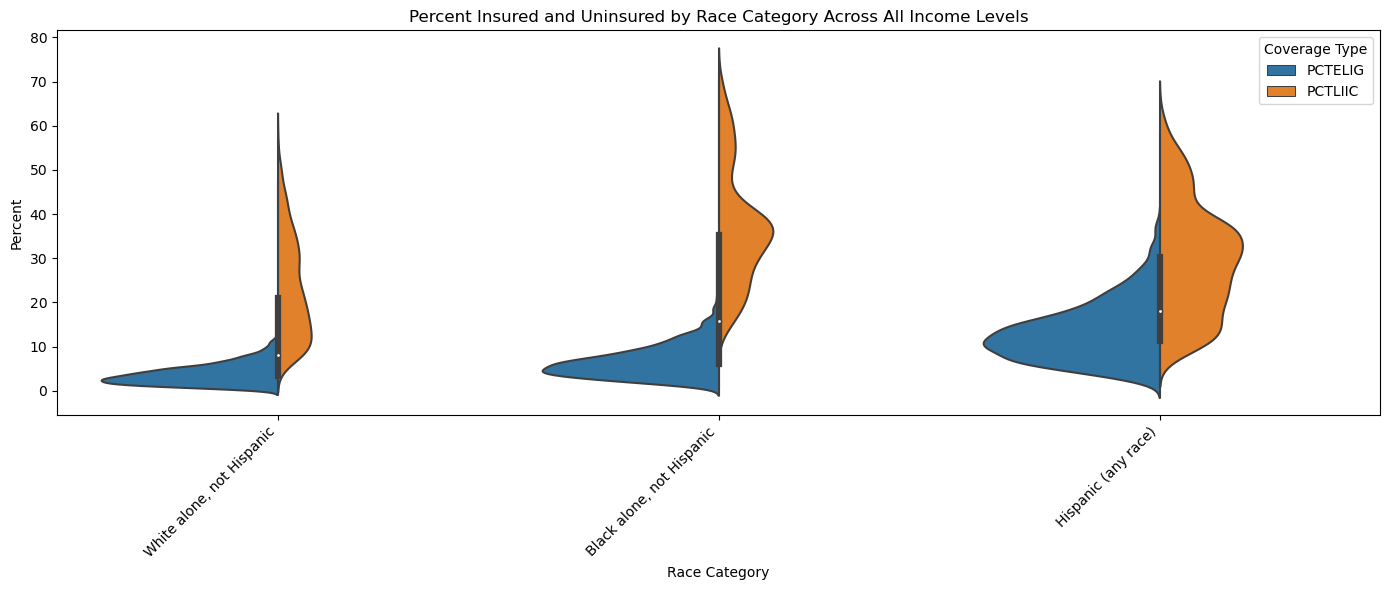

In [ ]:
### Your code
# creating a dataframe with only the columns needed for the violin plot
# using copy so I can work with this version without changing the original dataframe
violin_df = df[["racecat", "iprcat", "PCTELIG", "PCTLIIC"]].copy()

# reshaping PCTELIG and PCTLIIC into one percent column, just looked up how to do melt since it made the most sense to combine these into one column 
# this makes it easier to compare uninsured and insured percentages in the same violin plot
violin_df_long = pd.melt(
    violin_df,
    id_vars=["racecat", "iprcat"],
    value_vars=["PCTELIG", "PCTLIIC"],
    var_name="Coverage Type",
    value_name="Percent"
)

# setting the figure size so the violin plot is easier to read
plt.figure(figsize=(14, 6))

# creating a violin plot to compare percent uninsured and insured by race category
# split=True shows both coverage types inside the same violin for easier comparison
sns.violinplot(
    data=violin_df_long,
    x="racecat",
    y="Percent",
    hue="Coverage Type",
    split=True
)

# adding titles and axis labels
plt.title("Percent Insured and Uninsured by Race Category Across All Income Levels")
plt.xlabel("Race Category")
plt.ylabel("Percent")

# rotating x-axis labels so the race category names are easier to read
plt.xticks(rotation=45, ha="right")

# adding a legend to show which side represents each coverage type
plt.legend(title="Coverage Type")

# tightening the layout so the labels and title fit better
plt.tight_layout()

plt.show()

# Relationship plot
Is there any correlation between the average number of uninsured (`Mean_NUI`) for income level at Between 138% - 400% of poverty and the total population in each state in 2020?

*_Note: The numerical data in the US population dataset might need cleaning_

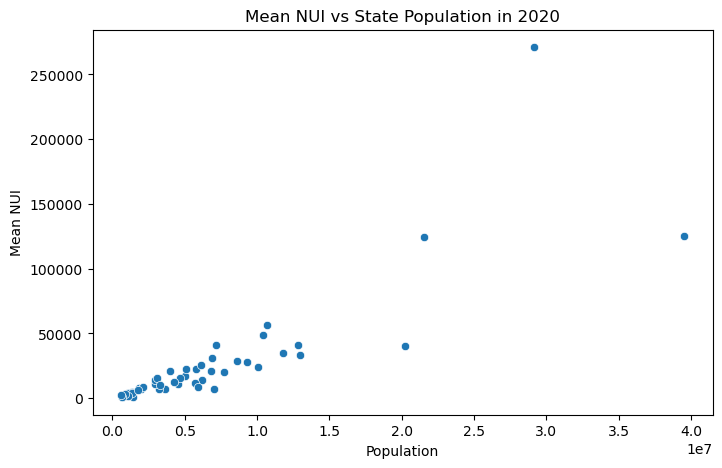

In [82]:
### Your code
# reading the population dataset
# using thousands="," because the population numbers have commas in them which was causing issues
# got the csv for 2020s population census
pop_df = pd.read_csv(
    "population.csv",
    thousands=","
)

# saving the income category I want to compare
# this makes the filter easier to read and reuse
income_filter = "Between 138% - 400% of poverty"

# filtering to the income category needed and finding the average NUI for each state
# renaming columns so the merge is easier to understand later
mean_nui_df = (
    df[df["iprcat"] == income_filter]
    .groupby("state_name_clean")["NUI"]
    .mean()
    .reset_index()
    .rename(columns={"state_name_clean": "state_name", "NUI": "Mean_NUI"})
)

# merging the average NUI dataframe with the population dataframe
# inner join keeps only the states that appear in both datasets
relationship_df = mean_nui_df.merge(
    pop_df,
    left_on="state_name",
    right_on="State",
    how="inner"
)

# checking the correlation between average number of uninsured and total population
# this helps show whether states with larger populations also tend to have higher Mean_NUI
relationship_df[["Mean_NUI", "Population"]].corr()

# creating a scatterplot to visualize the relationship between population and Mean_NUI
# this helps show if the correlation looks positive, negative, or weak
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=relationship_df,
    x="Population",
    y="Mean_NUI"
)

# adding titles and axis labels
plt.title("Mean NUI vs State Population in 2020")
plt.xlabel("Population")
plt.ylabel("Mean NUI")

plt.show()

The scatterplot suggests a positive relationship between state population and Mean_NUI. Larger states tend to have a higher average number of uninsured people, which makes sense because states with more people usually have a larger number of uninsured residents. However, the relationship is not perfect because some states may have higher or lower uninsured averages based on other factors besides population.

## Feature engineering and visualization
Create a new variable `UIrate` by calculating the average uninsured rate which is equal to $\large\frac{Mean\_NUI}{Population}*100$.  
Store the `ave_uninsured_rate` values in a new column `UIrate` added to the dataframe. Sort the dataframe by `UIrate` in descending order and create a bar plot to visualized the uninsured rate in the United States from the highest to the lowest.

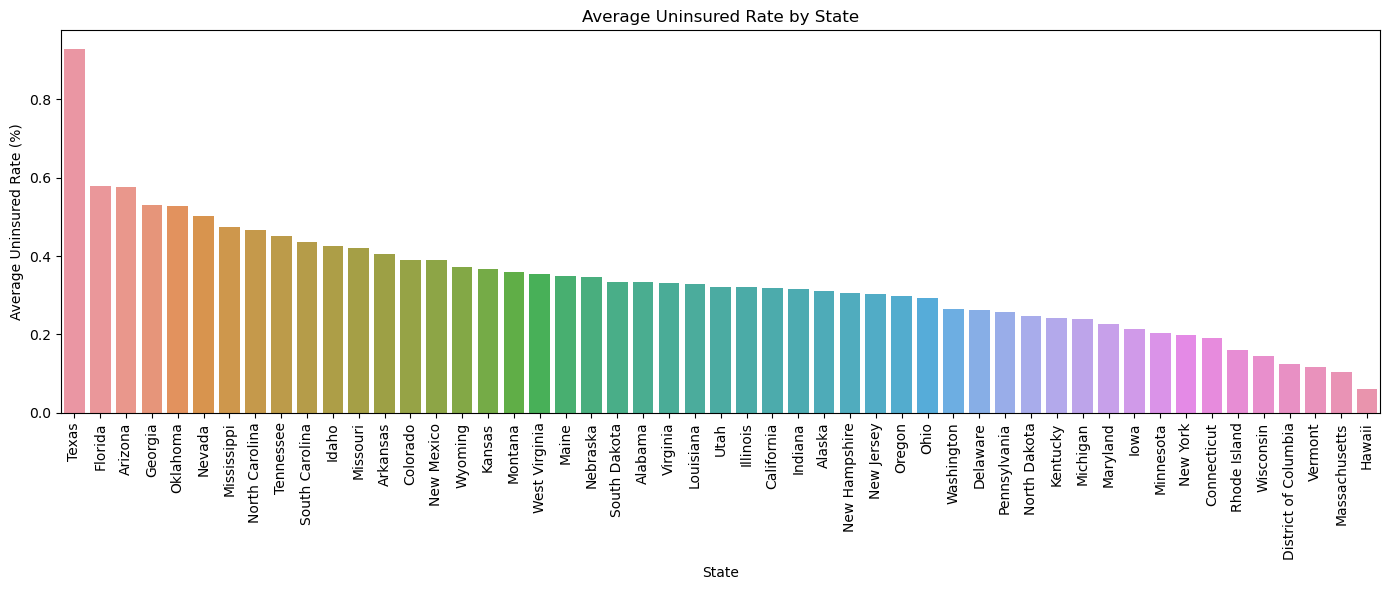

,state_name,Mean_NUI,Population,UIrate
43,Texas,271050.923077,29145505,0.929992
9,Florida,124814.227273,21538187,0.579502
2,Arizona,41292.000000,7151502,0.577389
10,Georgia,56746.708333,10711908,0.529754
36,Oklahoma,20931.333333,3959353,0.528655
28,Nevada,15628.708333,3104614,0.503403
24,Mississippi,14028.916667,2961279,0.473745
33,North Carolina,48585.083333,10439388,0.465402
42,Tennessee,31110.090909,6910840,0.450164
40,South Carolina,22375.578947,5118425,0.437158


In [83]:
### Your code

# creating a new uninsured rate column
# dividing Mean_NUI by Population and multiplying by 100 to turn it into a percentage
relationship_df["UIrate"] = (
    relationship_df["Mean_NUI"] / relationship_df["Population"]
) * 100

# sorting by UIrate so the states with the highest uninsured rate show first
relationship_df = relationship_df.sort_values(
    by="UIrate",
    ascending=False
)

# setting the figure size so the state labels are easier to read
plt.figure(figsize=(14, 6))

# creating a bar plot to compare uninsured rates across states
# this shows which states have the highest and lowest average uninsured rates
sns.barplot(
    data=relationship_df,
    x="state_name",
    y="UIrate"
)

# adding titles and axis labels
plt.title("Average Uninsured Rate by State")
plt.xlabel("State")
plt.ylabel("Average Uninsured Rate (%)")

# rotating x-axis labels because there are many state names
plt.xticks(rotation=90)

# tightening the layout so the labels fit better
plt.tight_layout()

plt.show()

# displaying the important columns to check the values behind the graph
relationship_df[["state_name", "Mean_NUI", "Population", "UIrate"]]

The UIrate bar plot shows the uninsured rate adjusted by state population. This is useful because Mean_NUI alone can make large states look like they have the biggest issue just because they have more people. UIrate helps compare states more fairly by showing the uninsured count as a percentage of the population.

# Machine learning
Machine learning model to predict percent uninsured in demographic group for all income levels.  

Given that the target variable for prediction is PCTELIG, which type of ML model would be the most appropriate and why?

***Your conclusions:***   
Please your reasoning of which ML model you believe would be the most appropriate and why?

Without any testing, I think a regression model would be best because PCTELIG is a numerical value, not a categorical value. Since the goal is to predict a percentage, regression fits this problem better than classification.

## Baseline Model
Start with a simple Linear or Logistic Regression model. Evaluate the model on its prediction.  

Include in your model the appropriate train-test split, cross-validation, scaling, and one-hot encoding. How did the model generalizes across the entire dataset?


In [84]:
### Your code
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.impute import SimpleImputer

# dropping rows where PCTELIG is missing because this is the value I am trying to predict
# keeping a copy so I do not change the original dataframe
model_df = df.dropna(subset=["PCTELIG"]).copy()

# selecting the columns that I want to use to predict PCTELIG
# using both demographic categories and insurance-related numeric columns
X = model_df[
    [
        "statefips",
        "agecat",
        "racecat",
        "sexcat",
        "iprcat",
        "NIPR",
        "NUI",
        "NIC",
        "PCTUI",
        "PCTIC",
        "PCTLIIC"
    ]
]

# setting PCTELIG as the target variable because this is what the model is predicting
y = model_df["PCTELIG"]

# listing the numeric features so they can be filled and scaled together
numeric_features = [
    "statefips",
    "NIPR",
    "NUI",
    "NIC",
    "PCTUI",
    "PCTIC",
    "PCTLIIC"
]

# listing the categorical features so they can be encoded into numeric columns
categorical_features = [
    "agecat",
    "racecat",
    "sexcat",
    "iprcat"
]

# setting up the numeric preprocessing
# using the median for missing values because it is less affected by outliers
# scaling after because linear regression can work better when numeric features are on similar scales
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

# setting up the categorical preprocessing
# using the most frequent value for missing categories and one-hot encoding to turn categories into numbers
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

# combining the numeric and categorical preprocessing steps
# this lets each type of column be handled the correct way before modeling
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

# creating the full model pipeline
# this runs preprocessing first and then trains the linear regression model
linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

# splitting the data into training and testing sets
# using 20% for testing so I can check the model on data it has not seen before
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# training the model using the training data
linear_model.fit(X_train, y_train)

# predicting PCTELIG for the test data
y_pred = linear_model.predict(X_test)

# calculating error metrics to see how far off the predictions are
# MAE shows the average error and RMSE gives more weight to larger errors
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# calculating r2 to see how much of the variation in PCTELIG the model explains
r2 = r2_score(y_test, y_pred)

# printing the baseline model results
print("Linear Regression Baseline Model")
print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

# using 5-fold cross-validation to test the model on different splits of the data
# this helps check if the model generalizes well across the full dataset
cv_scores = cross_val_score(
    linear_model,
    X,
    y,
    cv=5,
    scoring="r2"
)

# printing the cross-validation results and average score
print("Cross-validation R² scores:", cv_scores)
print("Average CV R²:", cv_scores.mean())

Linear Regression Baseline Model
MAE: 1.4633530586607948
RMSE: 2.1381142625775853
R² Score: 0.8739799589751838
Cross-validation R² scores: [0.86241094 0.87545978 0.87363515 0.87000666 0.85940671]
Average CV R²: 0.8681838472802472


***Your conclusions:***   
How did your model do? Expand on the how you evaluated if the model did a good job in informing us on the percentage of uninsured.

The Linear Regression baseline model did a good job predicting PCTELIG. The model had an MAE of about 1.46, which means the predictions were off by about 1.46 percentage points on average. The RMSE was about 2.14, which means larger errors were still relatively small overall, but RMSE is higher than MAE because it penalizes bigger mistakes more.

The R² score was about 0.874, meaning the model explained around 87.4% of the variation in PCTELIG on the test data. This suggests that the features used in the model were able to explain a large amount of the differences in uninsured percentages.

I also used 5-fold cross-validation to see if the model generalized well across the whole dataset instead of only doing well on one train-test split. The cross-validation R² scores were all close together, ranging from about 0.859 to 0.875, with an average of about 0.868. Since the cross-validation average is close to the test R² score, the model seems stable and does not look like it is only performing well because of one lucky split.

Overall, the Linear Regression model is a strong baseline for predicting percent uninsured. It gives low prediction error and a high R² score, so it does a good job informing us about the percentage of uninsured across demographic groups. More advanced regression models could still be tested later, but this baseline already performs well.